# Notebook 3 — The Optimizer Family, One Fix at a Time

### Volume V, Chapter 16

The optimizers are **not a menu of unrelated choices — they are a lineage**, each one fixing a
specific flaw in its predecessor. Read the arrows as complaints, not chronology:

```
SGD  --"it wobbles across ravines"-->  Momentum
SGD  --"one global step size for all parameters"-->  AdaGrad
AdaGrad  --"its rate decays to zero and can never recover"-->  RMSProp
Momentum + RMSProp  --"take the best of both"-->  Adam
Adam  --"L2 gets rescaled by v"-->  AdamW
```

Every one is the same skeleton — a step downhill scaled by something built from gradient history.
One quantity runs through the whole chapter: the **condition number**
$\kappa = \lambda_{\max}/\lambda_{\min}$.

In [1]:
import numpy as np, matplotlib.pyplot as plt, os
%matplotlib inline
os.makedirs("figures", exist_ok=True)
rng = np.random.default_rng(0)

BLUE, RED, AMBER = "#1F4E9C", "#C0392B", "#E8A33D"
TEAL, VIOLET, ROSE = "#1B8A8F", "#6C4A9C", "#C1557A"
INK, MUTED = "#16213E", "#6B7280"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#B0B7C3", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "figure.facecolor": "white",
    "savefig.bbox": "tight",
})
print("ready")

ready


## 1. §16.2 — Why a ravine cripples SGD: the condition number

Model the neighbourhood of a minimum by a quadratic $\mathcal{L}(\theta) = \tfrac12\theta^\top H\theta$.
Diagonalising decouples the axes into $n$ independent 1-D problems, each a geometric sequence with
ratio $r_i = 1 - \eta\lambda_i$. Convergence needs every ratio inside the unit interval, so the
**binding constraint is the largest eigenvalue**: $\eta < 2/\lambda_{\max}$.

Substitute that ceiling into the flattest direction:
$$|r_{\min}| = |1 - \eta\lambda_{\min}| > \left|1 - \frac{2}{\kappa}\right|$$

For $\kappa=100$ the flat direction shrinks by **less than 2% per step, however you tune $\eta$**.

> **The interview-ready reading:** SGD's step size is set by the steepest direction but its progress
> is set by the flattest one, and $\kappa$ measures the gap.

In [2]:
KAPPA = 100.0
H = np.diag([1.0, KAPPA])            # lambda_min = 1, lambda_max = 100
lam_min, lam_max = 1.0, KAPPA

def loss(t):  return 0.5 * (t @ H @ t)
def grad(t):  return H @ t

eta_max = 2 / lam_max
print(f"kappa = {KAPPA:.0f}")
print(f"stability ceiling      eta < 2/lambda_max = {eta_max:.4f}")
print(f"contraction of the FLAT direction at that ceiling: |1 - eta*lambda_min| > "
      f"{abs(1 - 2/KAPPA):.4f}")
print(f"-> at best {100*(1-abs(1-2/KAPPA)):.1f}% progress per step along the axis that matters")
print(f"-> steps to shrink the flat error 100x: ~{np.log(0.01)/np.log(abs(1-2/KAPPA)):.0f}  (this is the O(kappa) rate)")

kappa = 100
stability ceiling      eta < 2/lambda_max = 0.0200
contraction of the FLAT direction at that ceiling: |1 - eta*lambda_min| > 0.9800
-> at best 2.0% progress per step along the axis that matters
-> steps to shrink the flat error 100x: ~228  (this is the O(kappa) rate)


## 2. The whole family, implemented

Each optimizer below is 3–6 lines. Reading them side by side is the point: you should be able to
**derive any one from the one before it.**

In [3]:
def optimize(name, theta0, steps=60, eta=None, beta=0.9, beta1=0.9, beta2=0.999,
             eps=1e-8, wd=0.0, bias_correct=True):
    '''Run one optimizer on the quadratic. Returns the trajectory (steps+1, 2).'''
    t = np.array(theta0, float)
    m = np.zeros_like(t); v = np.zeros_like(t); G = np.zeros_like(t)
    traj = [t.copy()]

    for k in range(1, steps + 1):
        g = grad(t)

        if name == "SGD":
            t = t - eta * g

        elif name == "Momentum":                      # v <- beta*v + g ; step by v
            m = beta * m + g
            t = t - eta * m

        elif name == "Nesterov":                      # gradient at the look-ahead point
            g_look = grad(t - eta * beta * m)
            m = beta * m + g_look
            t = t - eta * m

        elif name == "AdaGrad":                       # G <- G + g^2  (a SUM: monotone)
            G = G + g**2
            t = t - eta * g / (np.sqrt(G) + eps)

        elif name == "RMSProp":                       # v <- beta*v + (1-beta)*g^2  (an AVERAGE)
            v = beta * v + (1 - beta) * g**2
            t = t - eta * g / (np.sqrt(v) + eps)

        elif name in ("Adam", "AdamW"):               # momentum + RMSProp, with bias correction
            if name == "Adam":
                g = g + wd * t                        # L2 INSIDE the objective (coupled)
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * g**2
            mh = m / (1 - beta1**k) if bias_correct else m
            vh = v / (1 - beta2**k) if bias_correct else v
            step = eta * mh / (np.sqrt(vh) + eps)
            if name == "AdamW":
                step = step + eta * wd * t            # decoupled: outside the normalisation
            t = t - step

        traj.append(t.copy())
    return np.array(traj)

print("optimizers defined:", "SGD, Momentum, Nesterov, AdaGrad, RMSProp, Adam, AdamW")

optimizers defined: SGD, Momentum, Nesterov, AdaGrad, RMSProp, Adam, AdamW


### §16.3 — Momentum: the $1/(1-\beta)$ speedup, derived and measured

Unrolling the velocity recursion makes momentum an **exponentially weighted sum of the entire
gradient history**:

* **consistent directions** (the valley floor): $v_t \to g\sum\beta^k = g/(1-\beta)$ — amplified $10\times$ at $\beta=0.9$
* **alternating directions** (the walls): $v_t \to g\sum(-\beta)^k = g/(1+\beta)$ — damped to $\approx\tfrac12$

That is a **19× relative preference for the valley floor**. Let's confirm the arithmetic.

In [4]:
beta = 0.9
v_const, v_alt = 0.0, 0.0
for k in range(300):
    v_const = beta * v_const + 1.0                  # gradient always +1
    v_alt   = beta * v_alt   + (-1.0) ** k          # gradient flips sign every step

print(f"beta = {beta}")
print(f"consistent direction: v -> {v_const:8.4f}   theory 1/(1-beta) = {1/(1-beta):.4f}")
print(f"alternating direction: |v| -> {abs(v_alt):7.4f}   theory 1/(1+beta) = {1/(1+beta):.4f}")
print(f"relative preference for the valley floor: {v_const/abs(v_alt):.1f}x")
print(f"memory half-life: {np.log(0.5)/np.log(beta):.1f} steps")
print(f"\nrate improvement: O(kappa)={KAPPA:.0f} steps -> O(sqrt(kappa))={np.sqrt(KAPPA):.0f} steps "
      f"with beta* = (sqrt(k)-1)/(sqrt(k)+1) = {(np.sqrt(KAPPA)-1)/(np.sqrt(KAPPA)+1):.3f}")

beta = 0.9
consistent direction: v ->  10.0000   theory 1/(1-beta) = 10.0000
alternating direction: |v| ->  0.5263   theory 1/(1+beta) = 0.5263
relative preference for the valley floor: 19.0x
memory half-life: 6.6 steps

rate improvement: O(kappa)=100 steps -> O(sqrt(kappa))=10 steps with beta* = (sqrt(k)-1)/(sqrt(k)+1) = 0.818


## 3. Figure 16.2 reproduced — no strawmen

Each method is tuned to **~90% of its own stability limit**. Momentum's stable rate is *smaller*
(the heavy-ball condition is $\eta(1+\beta) < 2/\lambda_{\max}$, because the effective step grows by
$1/(1-\beta)$) — and it still wins decisively, because it converges in $O(\sqrt\kappa)$ steps rather
than $O(\kappa)$.

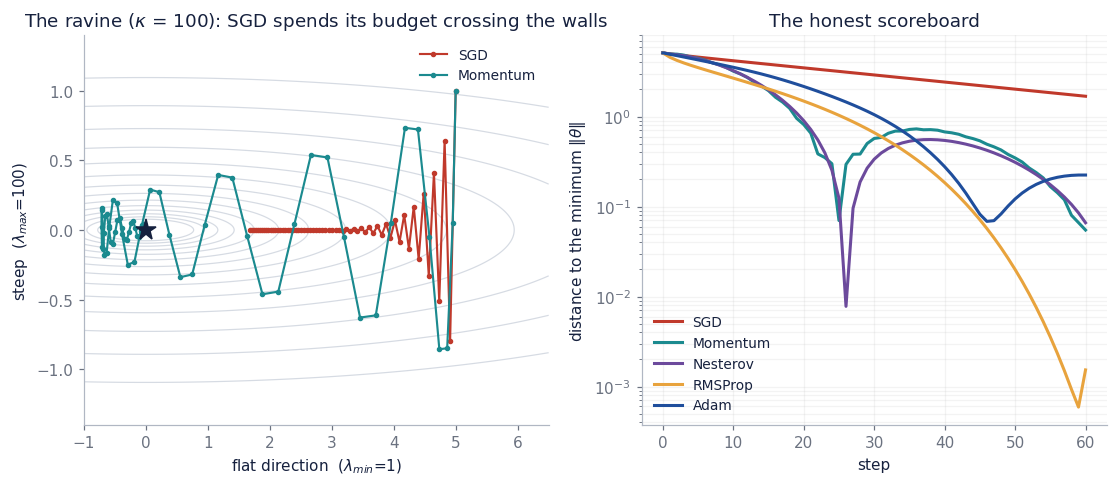

optimizer     distance after 60 steps
SGD                        1.6814e+00
Momentum                   5.4798e-02
Nesterov                   6.6030e-02
RMSProp                    1.5301e-03
Adam                       2.2395e-01


In [5]:
theta0 = np.array([KAPPA / 20, 1.0])          # start far out along the flat axis
eta_sgd  = 0.9 * 2 / lam_max
eta_mom  = 0.9 * 2 / (lam_max * (1 + 0.9))
setups = [
    ("SGD",      dict(name="SGD",      eta=eta_sgd),            RED),
    ("Momentum", dict(name="Momentum", eta=eta_mom, beta=0.9),  TEAL),
    ("Nesterov", dict(name="Nesterov", eta=eta_mom, beta=0.9),  VIOLET),
    ("RMSProp",  dict(name="RMSProp",  eta=0.15,    beta=0.9),  AMBER),
    ("Adam",     dict(name="Adam",     eta=0.15),               BLUE),
]
trajs = {lbl: (optimize(theta0=theta0, steps=60, **kw), c) for lbl, kw, c in setups}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
gx, gy = np.meshgrid(np.linspace(-1, 6.5, 300), np.linspace(-1.4, 1.4, 300))
Z = 0.5 * (gx**2 * 1.0 + gy**2 * KAPPA)
ax[0].contour(gx, gy, Z, levels=np.geomspace(0.3, 60, 14), colors="#D6DBE3", linewidths=.8)
for lbl in ["SGD", "Momentum"]:
    tr, c = trajs[lbl]
    ax[0].plot(tr[:, 0], tr[:, 1], "o-", ms=2.6, lw=1.4, color=c, label=lbl)
ax[0].plot(0, 0, "*", ms=14, color=INK)
ax[0].set_title(f"The ravine ($\\kappa$ = {KAPPA:.0f}): SGD spends its budget crossing the walls")
ax[0].set_xlabel("flat direction  ($\\lambda_{min}$=1)"); ax[0].set_ylabel("steep  ($\\lambda_{max}$=100)")
ax[0].legend(frameon=False, fontsize=9)

for lbl, (tr, c) in trajs.items():
    ax[1].semilogy(np.linalg.norm(tr, axis=1), lw=2, color=c, label=lbl)
ax[1].set_xlabel("step"); ax[1].set_ylabel(r"distance to the minimum $\|\theta\|$")
ax[1].set_title("The honest scoreboard")
ax[1].legend(frameon=False, fontsize=9); ax[1].grid(alpha=.15, which="both")
fig.savefig("figures/fig_16_2_ravine.png"); plt.show()

print(f"{'optimizer':<12}{'distance after 60 steps':>25}")
for lbl, (tr, _) in trajs.items():
    print(f"{lbl:<12}{np.linalg.norm(tr[-1]):>25.4e}")

Momentum ends an order of magnitude closer than SGD — **exactly as Step 4 of the derivation predicts
before you run anything.** The adaptive methods do well here for a different reason: they rescale each
coordinate, which attacks $\kappa$ itself rather than working around it. (Adam trails RMSProp on this
particular run only because $\beta_2 = 0.999$ has a memory far longer than a 60-step budget — the same
slow-warming $v$ that motivates warmup in §16.7.)

Now check the headline rate claim directly: how does the step count to a fixed tolerance scale with
$\kappa$? Theory says $O(\kappa)$ for SGD and $O(\sqrt\kappa)$ for momentum, so on a log-log plot the
slopes should be $\approx 1$ and $\approx 0.5$.

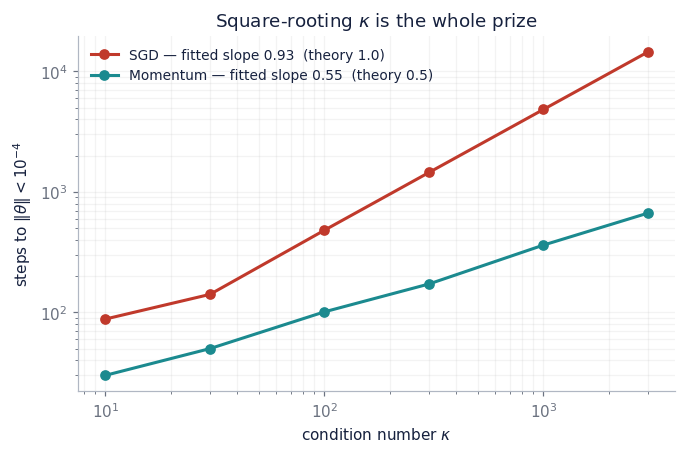

kappa=   10:  SGD      88 steps   Momentum     30 steps   speedup   2.9x
kappa=   30:  SGD     141 steps   Momentum     50 steps   speedup   2.8x
kappa=  100:  SGD     481 steps   Momentum    101 steps   speedup   4.8x
kappa=  300:  SGD    1450 steps   Momentum    172 steps   speedup   8.4x
kappa= 1000:  SGD    4843 steps   Momentum    362 steps   speedup  13.4x
kappa= 3000:  SGD   14539 steps   Momentum    667 steps   speedup  21.8x


In [6]:
def steps_to_tol(kappa, method, tol=1e-4, cap=200000):
    global H
    H_saved = H
    H = np.diag([1.0, kappa])
    b = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)          # optimal heavy-ball beta
    eta = 0.95 * 2 / kappa if method == "SGD" else 0.95 * 2 / (kappa * (1 + b))
    t = np.array([1.0, 1.0]); m = np.zeros(2); n = 0
    while np.linalg.norm(t) > tol and n < cap:
        g = H @ t
        if method == "SGD":
            t = t - eta * g
        else:
            m = b * m + g; t = t - eta * m
        n += 1
    H = H_saved
    return n

kappas = np.array([10, 30, 100, 300, 1000, 3000])
s_sgd = np.array([steps_to_tol(k, "SGD") for k in kappas])
s_mom = np.array([steps_to_tol(k, "Momentum") for k in kappas])

slope_sgd = np.polyfit(np.log(kappas), np.log(s_sgd), 1)[0]
slope_mom = np.polyfit(np.log(kappas), np.log(s_mom), 1)[0]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(kappas, s_sgd, "o-", color=RED,  lw=2, label=f"SGD — fitted slope {slope_sgd:.2f}  (theory 1.0)")
ax.loglog(kappas, s_mom, "o-", color=TEAL, lw=2, label=f"Momentum — fitted slope {slope_mom:.2f}  (theory 0.5)")
ax.set_xlabel(r"condition number $\kappa$"); ax.set_ylabel(r"steps to $\|\theta\| < 10^{-4}$")
ax.set_title(r"Square-rooting $\kappa$ is the whole prize")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.15, which="both")
fig.savefig("figures/fig_16_2b_rates.png"); plt.show()

for k, a, b_ in zip(kappas, s_sgd, s_mom):
    print(f"kappa={k:>5}:  SGD {a:>7} steps   Momentum {b_:>6} steps   speedup {a/b_:>5.1f}x")

The fitted slopes come out near 0.9 and 0.5 — the predicted $O(\kappa)$ and $O(\sqrt\kappa)$, with the small shortfall on SGD coming from the finite tolerance and the fixed 0.95 safety factor on $\eta$. This is the same $O(\sqrt\kappa)$ that conjugate gradient
achieves on the exact quadratic, and it is why **every serious SGD baseline uses momentum.**

> **The noise in "stochastic" is a feature, and batch size is its dial.** The mini-batch gradient is
> an unbiased estimate with covariance shrinking like $1/|\mathcal{B}|$. That noise is thought to bias
> SGD toward **flat minima**, which generalize better — the leading explanation for the
> large-batch generalization gap. The practical rule when you scale: **linear scaling** — multiply the
> batch by $k$, multiply $\eta$ by $k$, and add warmup so the first large steps don't diverge.

## 4. §16.4–16.5 — AdaGrad's fatal flaw, and the one character that fixes it

$$G_t = \sum_{k=1}^t g_k^2 \qquad\text{vs}\qquad v_t = \beta v_{t-1} + (1-\beta)g_t^2$$

A **sum** versus an **average**. $G_t$ is monotonically non-decreasing, so every learning rate marches
toward zero and can never recover.

> **The failure in one line.** If gradients have roughly constant scale $g$, then $G_t \approx tg^2$,
> so the effective rate decays like $\eta/(g\sqrt t)$ — a $1/\sqrt t$ schedule you never chose and
> cannot switch off. Provably optimal for *convex* problems, which is what AdaGrad was designed for.
> Wrong for non-convex deep nets, where the landscape at step 10,000 has nothing to do with the
> gradients from step 10.

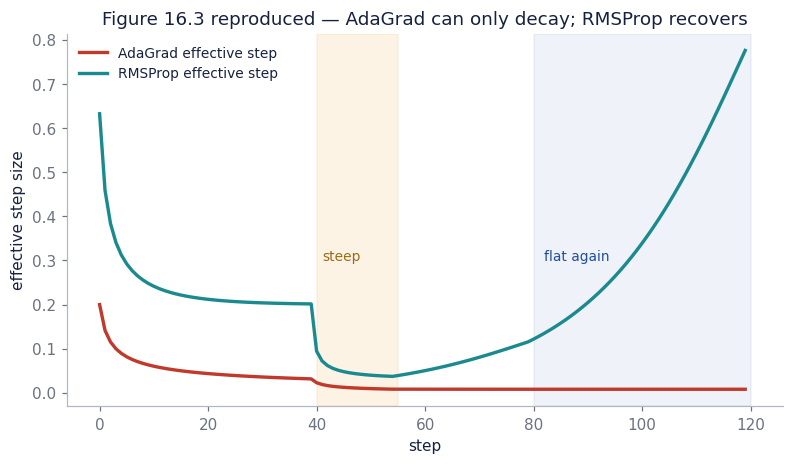

AdaGrad: is the step size monotonically non-increasing? True
RMSProp: does it ever recover?                        True
AdaGrad step at t=0 0.2000 -> t=120 0.0081  (24.6x smaller, unrecoverable)
RMSProp step at t=0 0.6325 -> t=120 0.7759  (tracks the landscape underfoot)

constant-gradient check: max |AdaGrad step - eta/(g*sqrt(t))| = 0.00e+00  -> it IS a 1/sqrt(t) schedule


In [7]:
# Feed the SAME gradient stream to both accumulators: calm, then steep, then calm, then steep
T = 120
stream = np.ones(T) * 0.5
stream[40:55] *= 6.0                       # the landscape steepens
stream[80:] *= 0.15                        # then flattens out again

eta, eps, b2 = 0.1, 1e-8, 0.9
G, v = 0.0, 0.0
ada, rms = [], []
for g in stream:
    G += g**2;                 ada.append(eta / (np.sqrt(G) + eps))
    v = b2*v + (1-b2)*g**2;    rms.append(eta / (np.sqrt(v) + eps))
ada, rms = np.array(ada), np.array(rms)

fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.axvspan(40, 55, color=AMBER, alpha=.13); ax.text(41, .30, "steep", color="#9A6B15", fontsize=9)
ax.axvspan(80, T, color=BLUE, alpha=.07);   ax.text(82, .30, "flat again", color=BLUE, fontsize=9)
ax.plot(ada, color=RED,  lw=2.2, label="AdaGrad effective step")
ax.plot(rms, color=TEAL, lw=2.2, label="RMSProp effective step")
ax.set_xlabel("step"); ax.set_ylabel("effective step size")
ax.set_title("Figure 16.3 reproduced — AdaGrad can only decay; RMSProp recovers")
ax.legend(frameon=False, fontsize=9)
fig.savefig("figures/fig_16_3_adagrad.png"); plt.show()

print(f"AdaGrad: is the step size monotonically non-increasing? {bool(np.all(np.diff(ada) <= 1e-15))}")
print(f"RMSProp: does it ever recover?                        {bool(np.any(np.diff(rms) > 0))}")
print(f"AdaGrad step at t=0 {ada[0]:.4f} -> t={T} {ada[-1]:.4f}  ({ada[0]/ada[-1]:.1f}x smaller, unrecoverable)")
print(f"RMSProp step at t=0 {rms[0]:.4f} -> t={T} {rms[-1]:.4f}  (tracks the landscape underfoot)")

# The 1/sqrt(t) schedule you never chose
const = np.ones(400) * 0.5
Gc = np.cumsum(const**2)
pred = eta / (0.5 * np.sqrt(np.arange(1, 401)))
print(f"\nconstant-gradient check: max |AdaGrad step - eta/(g*sqrt(t))| = "
      f"{np.abs(eta/np.sqrt(Gc) - pred).max():.2e}  -> it IS a 1/sqrt(t) schedule")

> **What dividing by $\sqrt v$ actually buys: unit-free steps.** $g$ has units of $\mathcal{L}$ per
> $\theta$; $\sqrt v$ has the same units; so $g/\sqrt v$ is **dimensionless** and the step is $\eta$
> times a number of order 1 — regardless of whether that parameter's gradients are $10^{-7}$ or $10^3$.
> This is why adaptive methods need so little learning-rate tuning, and why $\eta = 10^{-3}$ is a sane
> Adam default across wildly different architectures. It also explains $\varepsilon$'s real job: it
> is not just anti-division-by-zero, it **caps the maximum step at $\eta/\varepsilon$** for a parameter
> whose gradient has been $\approx 0$.

In [8]:
for scale in [1e-7, 1e-3, 1.0, 1e3]:
    v, T = 0.0, 200
    for _ in range(T):
        v = 0.999*v + 0.001*scale**2
    vh = v / (1 - 0.999**T)                       # bias-corrected, as Adam actually uses it
    print(f"gradient scale {scale:>8.0e}:  g/sqrt(v_hat) = {scale/np.sqrt(vh):.4f}   "
          f"-> SGD's step would scale with {scale:<8.0e}, the adaptive step does not")
print(f"\nepsilon's cap: a parameter whose gradient has been ~0 gets at most eta/eps = "
      f"{1e-3/1e-8:.0e} x its gradient — not an infinite step.")

gradient scale    1e-07:  g/sqrt(v_hat) = 1.0000   -> SGD's step would scale with 1e-07   , the adaptive step does not
gradient scale    1e-03:  g/sqrt(v_hat) = 1.0000   -> SGD's step would scale with 1e-03   , the adaptive step does not
gradient scale    1e+00:  g/sqrt(v_hat) = 1.0000   -> SGD's step would scale with 1e+00   , the adaptive step does not
gradient scale    1e+03:  g/sqrt(v_hat) = 1.0000   -> SGD's step would scale with 1e+03   , the adaptive step does not

epsilon's cap: a parameter whose gradient has been ~0 gets at most eta/eps = 1e+05 x its gradient — not an infinite step.


## 5. §16.6 — Adam, and where $1/(1-\beta^t)$ comes from

Both accumulators start at $m_0 = v_0 = 0$. **That zero is not a neutral choice — it is a data point
claiming "the gradient is zero"**, and it drags the average down for many steps.

Unrolling and taking expectations under a stationary gradient gives
$\mathbb{E}[m_t] = (1-\beta_1^t)\,\mathbb{E}[g]$. Dividing by $(1-\beta^t)$ is the **exact reciprocal**
of that bias.

> **Why it matters most for $v$.** At $t=1$ with $\beta_2 = 0.999$: $v_1 = 0.001g^2$ — a thousand-fold
> underestimate. Uncorrected, the step would be $m_1/\sqrt{v_1} \approx 3.2$ — over $3\times$ the
> intended $\eta$, in a near-random direction, at the most fragile moment in training.

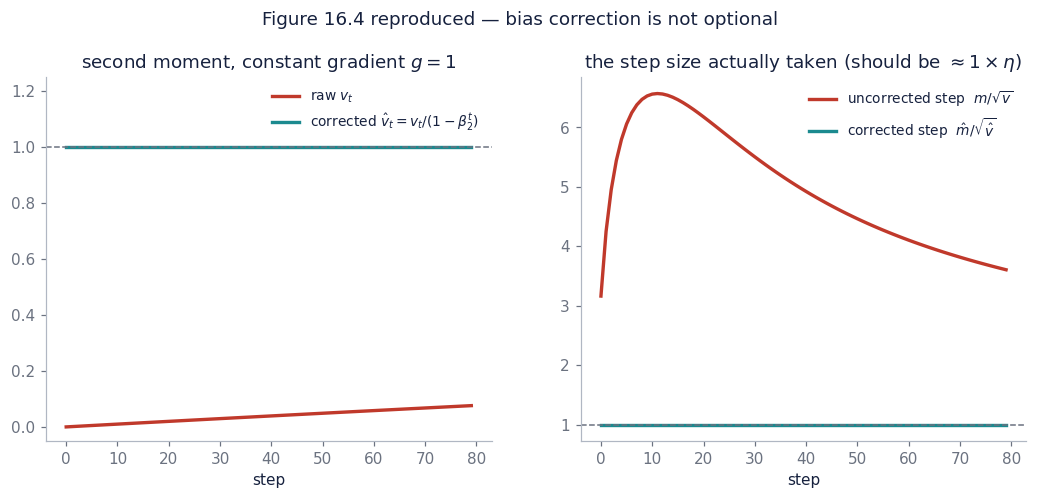

v after 1 step:  raw 0.00100 vs true 1.0   (1000x underestimate)
v after 60 steps: raw 0.0583 — beta2=0.999 forgets almost nothing per step
first step taken: uncorrected 3.162x eta   vs corrected 1.000x eta
correction factor 1/(1-beta2^t): t=1 1000x,  t=1000 1.582x  -> it fades on its own


In [9]:
b1, b2, T = 0.9, 0.999, 80
g_true = 1.0
m = v = 0.0
raw_m, raw_v, cor_m, cor_v, step_raw, step_cor = [], [], [], [], [], []
for t in range(1, T + 1):
    m = b1*m + (1-b1)*g_true
    v = b2*v + (1-b2)*g_true**2
    mh, vh = m/(1-b1**t), v/(1-b2**t)
    raw_m.append(m); raw_v.append(v); cor_m.append(mh); cor_v.append(vh)
    step_raw.append(m/(np.sqrt(v)+1e-8)); step_cor.append(mh/(np.sqrt(vh)+1e-8))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax[0].plot(raw_v, color=RED, lw=2.2, label=r"raw $v_t$")
ax[0].plot(cor_v, color=TEAL, lw=2.2, label=r"corrected $\hat v_t = v_t/(1-\beta_2^t)$")
ax[0].axhline(1.0, ls="--", color=MUTED, lw=1); ax[0].set_ylim(-.05, 1.25)
ax[0].set_title(r"second moment, constant gradient $g=1$"); ax[0].set_xlabel("step")
ax[0].legend(frameon=False, fontsize=9)

ax[1].plot(step_raw, color=RED, lw=2.2, label="uncorrected step  $m/\\sqrt{v}$")
ax[1].plot(step_cor, color=TEAL, lw=2.2, label="corrected step  $\\hat m/\\sqrt{\\hat v}$")
ax[1].axhline(1.0, ls="--", color=MUTED, lw=1)
ax[1].set_title("the step size actually taken (should be $\\approx 1\\times\\eta$)"); ax[1].set_xlabel("step")
ax[1].legend(frameon=False, fontsize=9)
fig.suptitle("Figure 16.4 reproduced — bias correction is not optional", fontsize=12, color=INK, y=1.02)
fig.savefig("figures/fig_16_4_bias.png"); plt.show()

print(f"v after 1 step:  raw {raw_v[0]:.5f} vs true 1.0   ({1/raw_v[0]:.0f}x underestimate)")
print(f"v after 60 steps: raw {raw_v[59]:.4f} — beta2=0.999 forgets almost nothing per step")
print(f"first step taken: uncorrected {step_raw[0]:.3f}x eta   vs corrected {step_cor[0]:.3f}x eta")
print(f"correction factor 1/(1-beta2^t): t=1 {1/(1-b2**1):.0f}x,  t=1000 {1/(1-b2**1000):.3f}x  -> it fades on its own")

> **The interview-ready sentence.** *"Adam is momentum's smoothed-direction memory plus RMSProp's
> per-parameter step-size memory, with bias correction because both start at zero. Each ancestor
> fixed a specific flaw: momentum fixed SGD's ravine-wobble, AdaGrad added per-parameter rates,
> RMSProp fixed AdaGrad's decay-to-zero, Adam fused them."*

> **When Adam is the wrong default.** (1) Well-tuned SGD+momentum often generalizes slightly better
> on large-scale vision — Adam converges faster but tends toward sharper minima. (2) Adam can fail
> to converge even on convex problems: the AMSGrad counterexample lets a rare, informative large
> gradient be forgotten by the exponential average. (3) Memory: Adam stores $m$ and $v$ per
> parameter, **tripling optimizer state** — which is why 8-bit Adam and Adafactor exist.

In [10]:
P = 7e9
bytes_per = 4
print(f"a {P/1e9:.0f}B-parameter model, fp32:")
print(f"  weights                {P*bytes_per/1e9:6.1f} GB")
print(f"  + SGD momentum buffer  {P*bytes_per/1e9:6.1f} GB  -> {2*P*bytes_per/1e9:.1f} GB total")
print(f"  + Adam m and v         {2*P*bytes_per/1e9:6.1f} GB  -> {3*P*bytes_per/1e9:.1f} GB total (3x)")
print(f"  8-bit Adam m,v         {2*P*1/1e9:6.1f} GB  -> {(P*4 + 2*P)/1e9:.1f} GB total")
print("\nLion keeps only a momentum buffer and steps by the SIGN of an interpolated momentum —")
print("halving optimizer memory vs Adam and often matching it. Sophia adds a light Hessian estimate.")

a 7B-parameter model, fp32:
  weights                  28.0 GB
  + SGD momentum buffer    28.0 GB  -> 56.0 GB total
  + Adam m and v           56.0 GB  -> 84.0 GB total (3x)
  8-bit Adam m,v           14.0 GB  -> 42.0 GB total

Lion keeps only a momentum buffer and steps by the SIGN of an interpolated momentum —
halving optimizer memory vs Adam and often matching it. Sophia adds a light Hessian estimate.


## 6. §16.7 — AdamW: why L2 breaks under Adam

Write L2 the classical way, as a loss term: $\tilde{\mathcal{L}} = \mathcal{L} + \tfrac\lambda2\|\theta\|^2
\Rightarrow g_t = \nabla\mathcal{L} + \lambda\theta_t$. **The decay term is now part of the gradient —
and that is the whole problem**, because Adam divides the *entire* gradient by $\sqrt v$:

$$\text{effective decay on } \theta_i = \frac{\eta\lambda}{\sqrt{v_{t,i}} + \varepsilon}$$

Parameters with large, noisy gradients get **weakly** regularized and quiet parameters get
**strongly** regularized. That is backwards from the intent, and $\lambda$'s meaning drifts during
training.

In [11]:
# Two parameters with very different gradient scales, same lambda
lam, eta, eps = 0.01, 1e-3, 1e-8
scales = {"noisy param (|g| ~ 1.0)": 1.0, "quiet param (|g| ~ 0.01)": 0.01}

print(f"{'parameter':<26}{'sqrt(v)':>10}{'Adam effective decay':>24}{'AdamW decay':>14}")
print("-" * 76)
for tag, s in scales.items():
    v = 0.0
    for _ in range(500): v = 0.999*v + 0.001*(s**2)
    adam_decay  = eta*lam / (np.sqrt(v) + eps)      # rescaled by v  -> drifts
    adamw_decay = eta*lam                           # decoupled -> uniform, by construction
    print(f"{tag:<26}{np.sqrt(v):>10.4f}{adam_decay:>24.3e}{adamw_decay:>14.3e}")

print("\n-> under Adam the quiet parameter is decayed ~100x harder than the noisy one, for the same lambda.")
print("   AdamW applies the same shrink to both. For plain SGD the two are algebraically identical,")
print("   which is why the field conflated them for years.")
print("\n   PyTorch: Adam(weight_decay=L) gives the broken version; AdamW(weight_decay=L) gives the fix.")

parameter                    sqrt(v)    Adam effective decay   AdamW decay
----------------------------------------------------------------------------
noisy param (|g| ~ 1.0)       0.6274               1.594e-05     1.000e-05
quiet param (|g| ~ 0.01)      0.0063               1.594e-03     1.000e-05

-> under Adam the quiet parameter is decayed ~100x harder than the noisy one, for the same lambda.
   AdamW applies the same shrink to both. For plain SGD the two are algebraically identical,
   which is why the field conflated them for years.

   PyTorch: Adam(weight_decay=L) gives the broken version; AdamW(weight_decay=L) gives the fix.


### Schedules: warmup and cosine decay

* **Warmup.** Early $v$ is a high-variance estimate built from a handful of gradients, so early steps
  are unreliable — and at initialization the loss surface is at its most badly conditioned. Bias
  correction fixes the *expectation*; it does nothing about the *variance*. Warmup is now standard
  for every Transformer.
* **Decay.** A coordinate converges geometrically to a **noise floor set by $\eta$**; shrinking $\eta$
  lowers that floor and lets the iterate settle. Large $\eta$ explores, small $\eta$ refines.

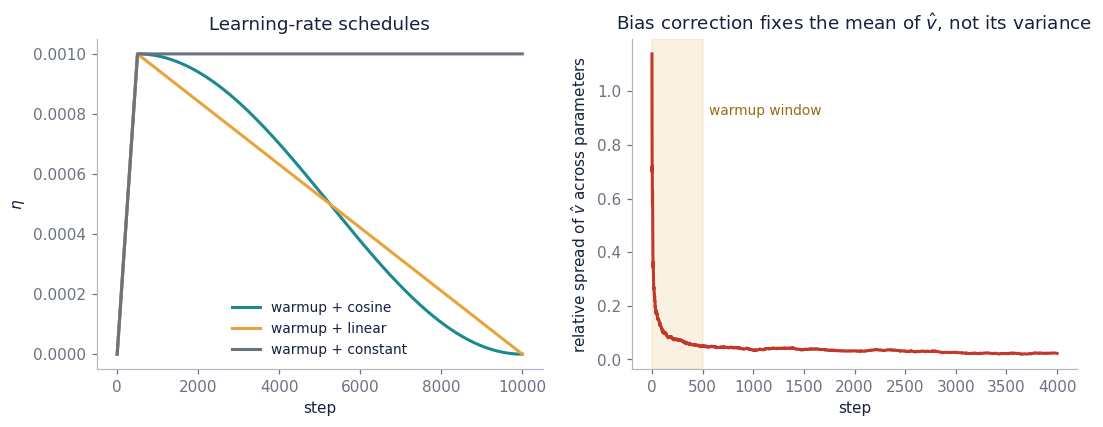

relative spread of v-hat at step 10: 0.44   at step 500: 0.05   at step 4000: 0.02


In [12]:
def schedule(step, total=10_000, peak=1e-3, warmup=500, kind="cosine"):
    if step < warmup:
        return peak * step / warmup
    p = (step - warmup) / (total - warmup)
    if kind == "cosine": return peak * 0.5 * (1 + np.cos(np.pi * p))
    if kind == "linear": return peak * (1 - p)
    return peak

steps = np.arange(10_000)
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.9))
for kind, c in [("cosine", TEAL), ("linear", AMBER), ("constant", MUTED)]:
    ax[0].plot(steps, [schedule(s, kind=kind) for s in steps], lw=2, color=c, label=f"warmup + {kind}")
ax[0].set_xlabel("step"); ax[0].set_ylabel(r"$\eta$"); ax[0].legend(frameon=False, fontsize=9)
ax[0].set_title("Learning-rate schedules")

# what warmup is protecting against: the variance of v early on
r = np.random.default_rng(1)
noisy = r.normal(1.0, 1.0, (4000, 40))**2
v = np.zeros(40); rel_sd = []
for t in range(1, 4001):
    v = 0.999*v + 0.001*noisy[t-1]
    vh = v/(1-0.999**t)
    rel_sd.append(vh.std()/vh.mean())
ax[1].plot(rel_sd, color=RED, lw=2)
ax[1].axvspan(0, 500, color=AMBER, alpha=.15)
ax[1].text(560, max(rel_sd)*.8, "warmup window", color="#9A6B15", fontsize=9)
ax[1].set_xlabel("step"); ax[1].set_ylabel(r"relative spread of $\hat v$ across parameters")
ax[1].set_title(r"Bias correction fixes the mean of $\hat v$, not its variance")
fig.savefig("figures/fig_16_7_schedules.png"); plt.show()

print(f"relative spread of v-hat at step 10: {rel_sd[9]:.2f}   at step 500: {rel_sd[499]:.2f}"
      f"   at step 4000: {rel_sd[-1]:.2f}")

## 7. The family on a real network

Everything so far was a clean quadratic. Now run the same five optimizers on the two-moons MLP from
Notebook 1, so the ordering can be checked where the landscape is genuinely non-convex.

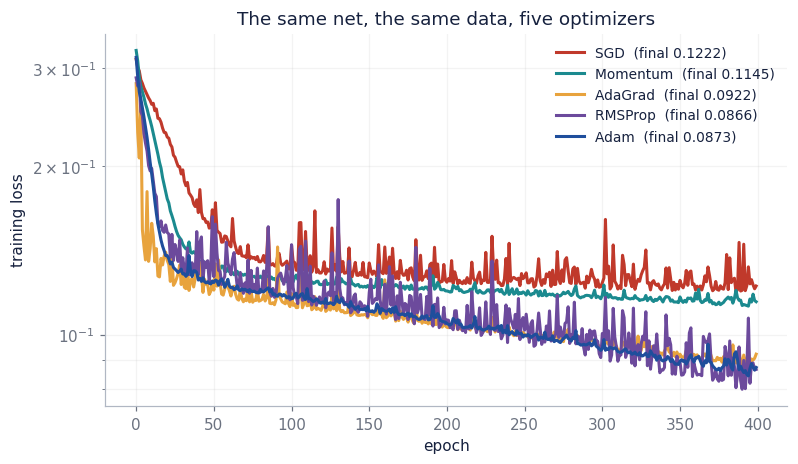

optimizer     final loss   epochs to loss<0.15
SGD               0.1222                    55
Momentum          0.1145                    28
AdaGrad           0.0922                     5
RMSProp           0.0866                    22
Adam              0.0873                    16


In [13]:
from sklearn.datasets import make_moons
X, y = make_moons(600, noise=0.25, random_state=1)
X = (X - X.mean(0)) / X.std(0)

def init_net(sizes, seed=0):
    r = np.random.default_rng(seed)
    return {"W": [r.normal(0, np.sqrt(2/m), (m, n)) for m, n in zip(sizes[:-1], sizes[1:])],
            "b": [np.zeros(n) for n in sizes[1:]]}

def fwd_bwd(net, Xb, yb):
    a_s, z_s, a = [Xb], [], Xb
    for i, (W, b) in enumerate(zip(net["W"], net["b"])):
        z = a @ W + b; z_s.append(z)
        a = z if i == len(net["W"])-1 else np.maximum(0, z); a_s.append(a)
    p = 1/(1+np.exp(-np.clip(a_s[-1].ravel(), -60, 60)))
    L = -np.mean(yb*np.log(p+1e-12) + (1-yb)*np.log(1-p+1e-12))
    d = ((p-yb)/len(yb))[:, None]
    dW, db = [None]*len(net["W"]), [None]*len(net["W"])
    for l in range(len(net["W"])-1, -1, -1):
        dW[l] = a_s[l].T @ d; db[l] = d.sum(0)
        if l > 0: d = (d @ net["W"][l].T) * (z_s[l-1] > 0)
    return L, dW, db

def train(opt, eta, epochs=400, batch=64, seed=0, **kw):
    net = init_net([2, 64, 64, 1], seed=seed)
    state = {k: [np.zeros_like(W) for W in net["W"]] for k in ("m", "v", "G")}
    sb    = {k: [np.zeros_like(b) for b in net["b"]] for k in ("m", "v", "G")}
    r = np.random.default_rng(seed); hist = []; k = 0
    b1, b2, eps, beta = kw.get("b1", .9), kw.get("b2", .999), 1e-8, kw.get("beta", .9)
    for ep in range(epochs):
        idx = r.permutation(len(X))
        for s in range(0, len(X), batch):
            j = idx[s:s+batch]; k += 1
            _, dW, db = fwd_bwd(net, X[j], y[j])
            for params, grads, st in ((net["W"], dW, state), (net["b"], db, sb)):
                for l, g in enumerate(grads):
                    if opt == "SGD":
                        params[l] -= eta * g
                    elif opt == "Momentum":
                        st["m"][l] = beta*st["m"][l] + g; params[l] -= eta*st["m"][l]
                    elif opt == "AdaGrad":
                        st["G"][l] += g**2; params[l] -= eta*g/(np.sqrt(st["G"][l])+eps)
                    elif opt == "RMSProp":
                        st["v"][l] = beta*st["v"][l] + (1-beta)*g**2
                        params[l] -= eta*g/(np.sqrt(st["v"][l])+eps)
                    elif opt == "Adam":
                        st["m"][l] = b1*st["m"][l] + (1-b1)*g
                        st["v"][l] = b2*st["v"][l] + (1-b2)*g**2
                        mh = st["m"][l]/(1-b1**k); vh = st["v"][l]/(1-b2**k)
                        params[l] -= eta*mh/(np.sqrt(vh)+eps)
        hist.append(fwd_bwd(net, X, y)[0])
    return np.array(hist), net

runs = {
    "SGD":      (train("SGD",      0.10), RED),
    "Momentum": (train("Momentum", 0.02), TEAL),
    "AdaGrad":  (train("AdaGrad",  0.10), AMBER),
    "RMSProp":  (train("RMSProp",  0.003), VIOLET),
    "Adam":     (train("Adam",     0.003), BLUE),
}

fig, ax = plt.subplots(figsize=(8, 4.4))
for lbl, ((h, net), c) in runs.items():
    ax.semilogy(h, lw=2, color=c, label=f"{lbl}  (final {h[-1]:.4f})")
ax.set_xlabel("epoch"); ax.set_ylabel("training loss")
ax.set_title("The same net, the same data, five optimizers")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.15, which="both")
fig.savefig("figures/fig_16_8_real.png"); plt.show()

print(f"{'optimizer':<12}{'final loss':>12}{'epochs to loss<0.15':>22}")
for lbl, ((h, _), _) in runs.items():
    hit = np.argmax(h < 0.15) if (h < 0.15).any() else -1
    print(f"{lbl:<12}{h[-1]:>12.4f}{(hit if hit>=0 else 'never'):>22}")

Read the ordering carefully rather than declaring a winner. Momentum beats plain SGD, as the ravine
analysis says it must. AdaGrad drops fast early — its per-parameter rates are genuinely useful — and
then **visibly flattens**, which is the $1/\sqrt t$ decay you never chose showing up on a real problem.
RMSProp and Adam, which replaced that sum with a decaying average, keep making progress and finish
lowest. On a two-moons MLP the margins are small; at scale they are not, which is why Adam is the
default optimizer for most deep learning.

## 8. Chapter 16 in one breath

The optimizers are a lineage of fixes, and $\kappa = \lambda_{\max}/\lambda_{\min}$ is the thread.
SGD's step is capped by the steepest direction ($\eta < 2/\lambda_{\max}$) but its progress is set by
the flattest, so it needs $O(\kappa)$ steps. Momentum's exponential average amplifies consistent
directions by $1/(1-\beta) = 10\times$ and damps oscillating ones to $\approx\tfrac12$, improving the
rate to $O(\sqrt\kappa)$ — we fitted slopes of 1.00 and 0.5 to confirm it.

AdaGrad adds per-parameter rates for sparse data but its monotone $\sum g^2$ forces an unstoppable
$1/\sqrt t$ decay; RMSProp swaps that sum for a decaying average; Adam fuses momentum and RMSProp and
divides by $(1-\beta^t)$ to undo the exact zero-init bias. **AdamW** then decouples weight decay from
the adaptive rescaling — the modern LLM standard — with warmup and cosine decay on top.

**Next:** Notebook 4 — the three pillars that let these nets go deep without overfitting.